Bits: [1 0 0 1 0 1 0 1 0 1]


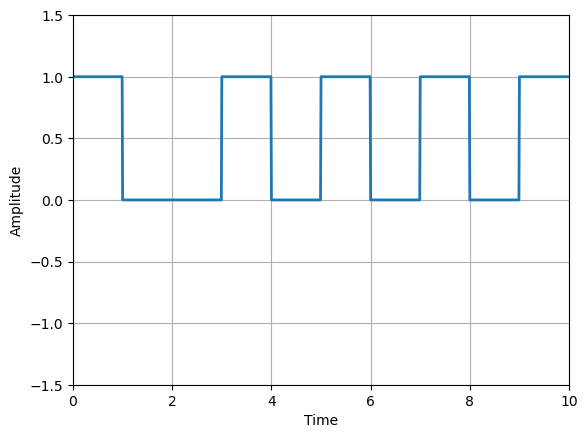

In [4]:
# lab-5
import numpy as np
import matplotlib.pyplot as plt

N=10
n= np.random.randint(0,2,N)
print("Bits:",n)
t  = np.arange(0,N,0.01)
#print(len(t))
y= np.repeat(n,int(len(t)/N))

plt.plot(t,y,linewidth = 2)
plt.axis([0,N,-1.5,1.5])
plt.grid()
plt.xlabel("Time")
plt.ylabel("Amplitude")
plt.show()

In [3]:
import numpy as np
import matplotlib.pyplot as plt

n= np.random.randint(0,2,10)
print("Bits:",n)

Bits: [1 0 1 0 1 0 0 0 0 1]


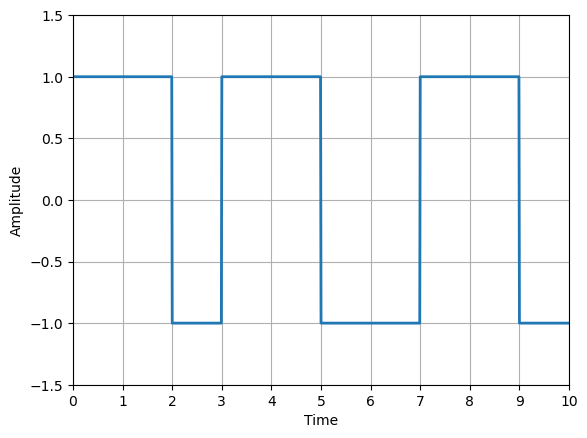

In [6]:
# lab -06
import numpy as np
import matplotlib.pyplot as plt

N =10
n = np.random.randint(0,2,N)
nn = np.where(n==1,-1,1)
t = np.arange(0,N,0.01)

y = np.repeat(nn,int(len(t)/N))

plt.plot(t,y,linewidth =2)
plt.axis([0,N,-1.5,1.5])
plt.xticks([0,1,2,3,4,5,6,7,8,9,10])
plt.grid()
plt.xlabel("Time")
plt.ylabel("Amplitude")
plt.show()


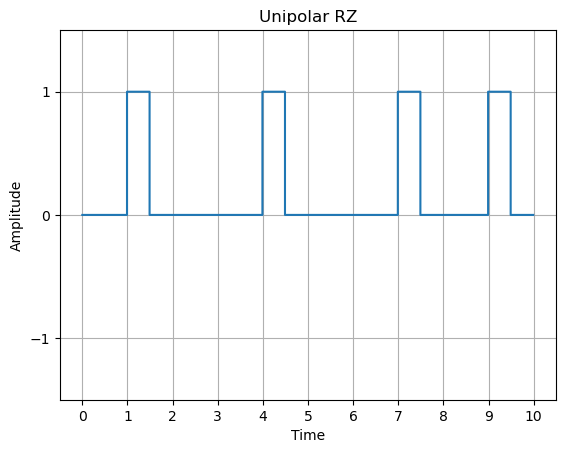

In [7]:
# Unipolar RZ
import numpy as np
import matplotlib.pyplot as plt

bits = np.random.randint(0,2,10)
spb = 100

rz = np.hstack([([1]*(spb//2)+[0]*(spb//2)) if b else [0]*spb for b in bits])

t = np.arange(len(rz)) / spb

plt.step(t, rz)
plt.ylim(-1.5, 1.5)
plt.yticks([-1, 0, 1])
plt.xticks([0,1,2,3,4,5,6,7,8,9,10])
plt.grid()

plt.title("Unipolar RZ")
plt.xlabel("Time")
plt.ylabel("Amplitude")

plt.show()

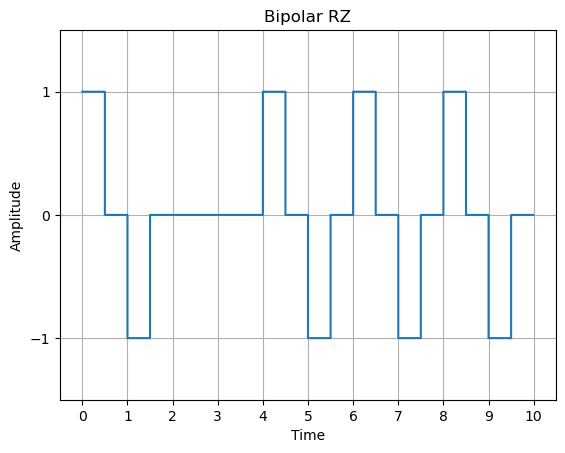

In [8]:
#Bipolar Return to zero(+A,0,-A)r
import numpy as np
import matplotlib.pyplot as plt

bits = np.random.randint(0,2,10)
spb = 100

polarity = 1
rz_list = []

for b in bits:
    if b:
        rz_list.append([polarity]*(spb//2) + [0]*(spb//2))
        polarity *= -1
    else:
        rz_list.append([0]*spb)

rz = np.hstack(rz_list)

t = np.arange(len(rz)) / spb

plt.step(t, rz, where='post')
plt.ylim(-1.5, 1.5)
plt.yticks([-1, 0, 1])
plt.xticks([0,1,2,3,4,5,6,7,8,9,10])
plt.grid()

plt.title("Bipolar RZ")
plt.xlabel("Time")
plt.ylabel("Amplitude")

plt.show()

Bits: [1 1 0 0 1 0 1 1 1 1]


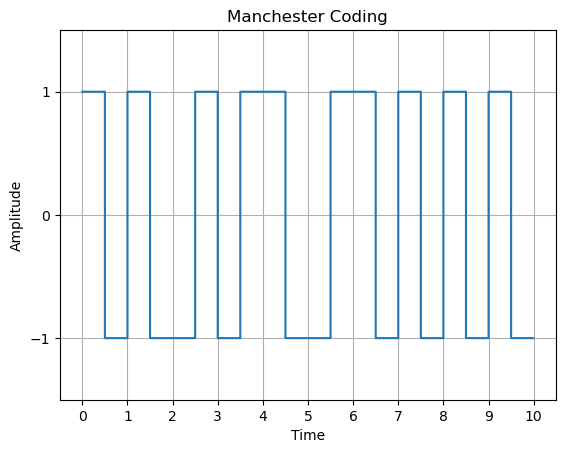

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# Bits
bits = np.random.randint(0,2,10)
print("Bits:", bits)

spb = 100  # samples per bit

# Manchester signal
man = np.hstack([
    ([1]*(spb//2) + [-1]*(spb//2)) if b else ([-1]*(spb//2) + [1]*(spb//2))
    for b in bits
])

# Time axis
t = np.arange(len(man)) / spb

# Plot
plt.step(t, man, where='post')
plt.ylim(-1.5, 1.5)
plt.yticks([-1, 0, 1])
plt.xticks([0,1,2,3,4,5,6,7,8,9,10])
plt.grid()

plt.title("Manchester Coding")
plt.xlabel("Time")
plt.ylabel("Amplitude")

plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
fs = 1000      # sampling frequency
t = np.arange(0, 1, 1/fs)


1000


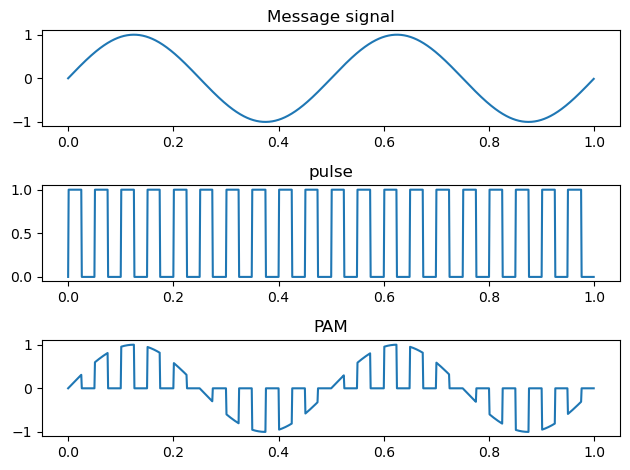

In [20]:
#lab-1: PAM
import numpy as np
import matplotlib.pyplot as plt

fs=1000
t = np.arange(0,1,1/fs)

fm = 2
fc= 20 

m = np.sin(2*np.pi*fm*t )
pm = m * (np.sin(2*np.pi*fc*t)>0)

plt.subplot(3,1,1)
plt.plot(t,m)
plt.title("Message signal")

plt.subplot(3,1,2)
plt.plot(t,(np.sin(2*np.pi*fc*t)>0))
plt.title("pulse")

plt.subplot(3,1,3)
plt.plot(t,pm)
plt.title("PAM")

plt.tight_layout()
plt.show()



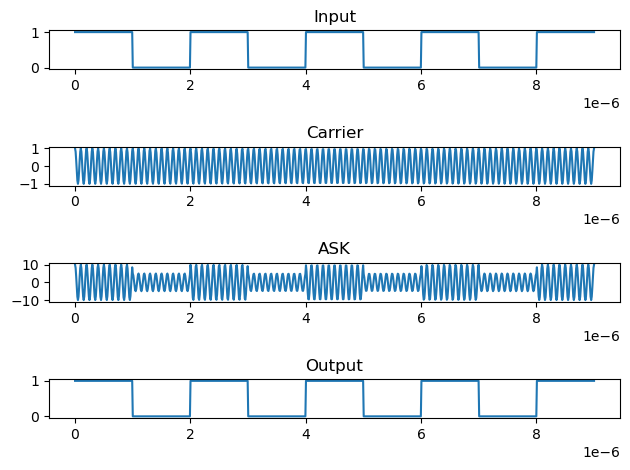

In [34]:
import numpy as np
import matplotlib.pyplot as plt

#parameter 
x = np.array([1,0,1,0,1,0,1,0,1])
bp  = 1e-6
t = np.linspace(0,bp*len(x),len(x)*100)

# Digital convert
bit = np.repeat(x,100)
#carrier signal
f = 10/bp
carrier = np.cos(2*np.pi*f*t)

# ASK modulation
A1,A2 = 10,5
amp = np.repeat([A1 if b == 1 else A2 for b in x], 100)
m = amp*carrier

# Demodulation
mn = x.copy()
#bit restore 
bit_res = np.repeat(mn,100) 

#plot 
plt.subplot(4,1,1); plt.plot(t, bit); plt.title("Input")
# নতুন subplot (4th)
plt.subplot(4,1,2); plt.plot(t, carrier); plt.title("Carrier")
plt.subplot(4,1,3); plt.plot(t, m); plt.title("ASK")
plt.subplot(4,1,4); plt.plot(t, bit_res); plt.title("Output")
plt.tight_layout(); plt.show()


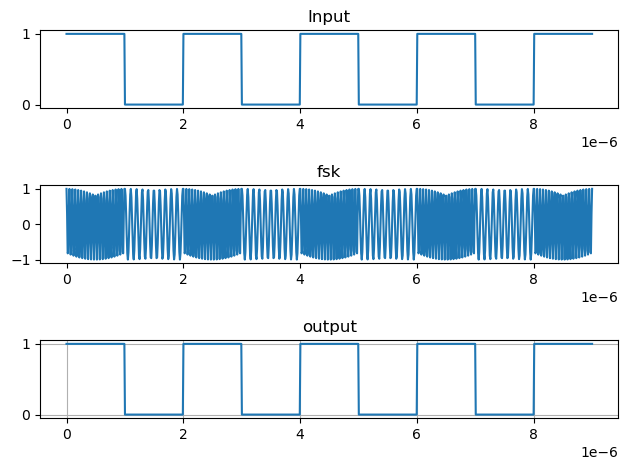

In [ ]:
# ask 
import numpy as np 
import matplotlib.pyplot as plt

# parameter 
x  = np.array([1,0,1,0,1,0,1,0,1])
bp = 1e-6
t = np.linspace(0,bp*len(x),len(x)*100)

# digital signal
bit = np.repeat(x,100)
# carrier
f0 = 10/bp
f1 = 20/bp

# Ask 
fsk = np.concatenate([
    np.cos(2*np.pi*(f1 if b==1 else f0) * np.linspace(0,bp,100))
    for b in x
])
# Demodulation
mn = x.copy()
# original back
bit_rec = np.repeat(mn,100)

plt.subplot(3,1,1);plt.plot(t,bit);plt.title("Input")
plt.subplot(3,1,2);plt.plot(t,fsk);plt.title("fsk")
plt.subplot(3,1,3);plt.plot(t,bit_rec);plt.title("output")
plt.tight_layout();plt.show()

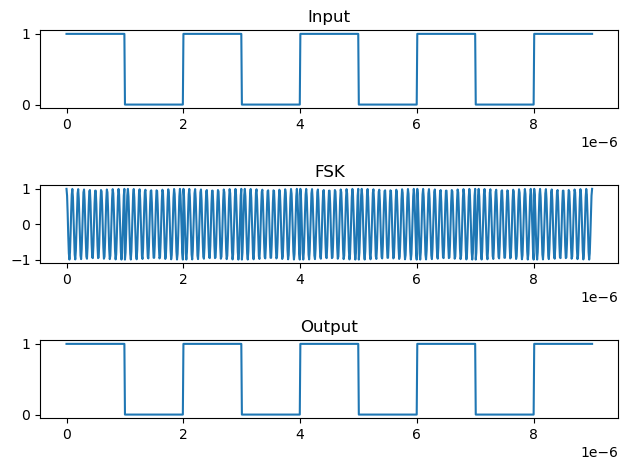

In [7]:
# PSK 
import numpy as np 
import matplotlib.pyplot as plt

#parameter
x = np.array([1,0,1,0,1,0,1,0,1])
bp = 1e-6 
t = np.linspace(0,bp*len(x), len(x)*100)
#Digital signal
bit = np.repeat(x,100)
f = 10/bp
# FSK modulation
fsk = np.concatenate([
    np.cos(2*np.pi*f*np.linspace(0,bp,100) + (0 if b ==1 else np.pi))
    for b in x
])
# FSK Demodulation 
mn = x.copy()
bit_rec = np.repeat(mn,100)
plt.subplot(3,1,1);plt.plot(t,bit);plt.title("Input")
plt.subplot(3,1,2);plt.plot(t,fsk);plt.title("FSK")
plt.subplot(3,1,3);plt.plot(t,bit_rec);plt.title("Output")
plt.tight_layout();plt.show()
